In [ ]:
import torch
import numpy as np
grid = torch.tensor(20,20)
kernel_moore = torch.tensor([1,1,1],
[1,0,1],
[1,1,1])
kernel_von = torch.tensor([0,1,0],
[1,0,1],
[0,1,0])

# outside grid always 0
#edge values are reflected
#the grid wraps arpind periodically
# periodic boundaries are convenient?????


In [8]:
import numpy as np
import matplotlib.pyplot as plt


def count_neighbors(grid):
    """
    Count the eight live neighbours of every cell.

    np.roll gives periodic boundary conditions:
    the top connects to the bottom and the left connects to the right.
    """
    neighbor_count = np.zeros_like(grid, dtype=np.uint8)

    for row_shift in (-1, 0, 1):
        for col_shift in (-1, 0, 1):

            # Do not count the centre cell itself.
            if row_shift == 0 and col_shift == 0:
                continue

            shifted_grid = np.roll(
                grid,
                shift=(row_shift, col_shift),
                axis=(0, 1)
            )

            neighbor_count += shifted_grid

    return neighbor_count


def game_of_life_step(grid):
    """
    Apply one synchronous Game of Life update.
    """
    neighbors = count_neighbors(grid)
    print(f"count_neighbors: \n{neighbors}")
    print("end")

    birth = (grid == 0) & (neighbors == 3)

    survival = (
        (grid == 1)
        & ((neighbors == 2) | (neighbors == 3))
    )

    next_grid = birth | survival

    return next_grid.astype(np.uint8)

In [9]:
grid = np.zeros((7, 7), dtype=np.uint8)

# Horizontal line of three live cells
grid[3, 2:5] = 1

print("Time 0:")
print(grid)

grid_1 = game_of_life_step(grid)

print("\nTime 1:")
print(grid_1)

grid_2 = game_of_life_step(grid_1)

print("\nTime 2:")
print(grid_2)

Time 0:
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 1 1 1 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]
count_neighbors: 
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 1 2 3 2 1 0]
 [0 1 1 2 1 1 0]
 [0 1 2 3 2 1 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]
end

Time 1:
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]
count_neighbors: 
[[0 0 0 0 0 0 0]
 [0 0 1 1 1 0 0]
 [0 0 2 1 2 0 0]
 [0 0 3 2 3 0 0]
 [0 0 2 1 2 0 0]
 [0 0 1 1 1 0 0]
 [0 0 0 0 0 0 0]]
end

Time 2:
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 1 1 1 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


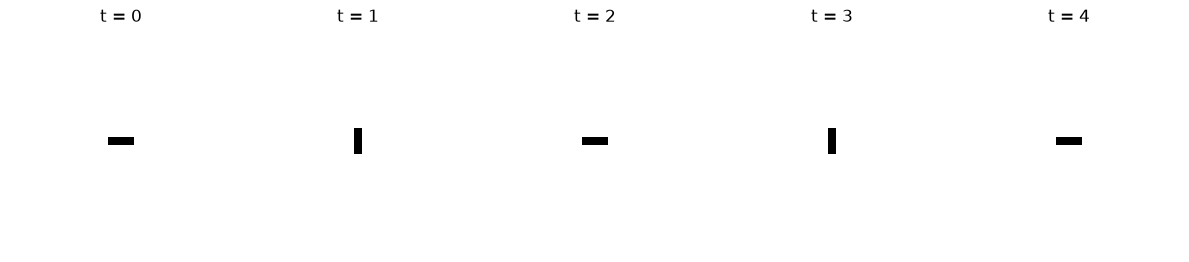

In [3]:
grid = np.zeros((25, 25), dtype=np.uint8)
grid[12, 11:14] = 1

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for step, ax in enumerate(axes):
    ax.imshow(grid, cmap="binary", vmin=0, vmax=1)
    ax.set_title(f"t = {step}")
    ax.axis("off")

    grid = game_of_life_step(grid)

plt.tight_layout()
plt.show()

grid: 
 [[0 0 0 ... 0 0 1]
 [1 1 0 ... 1 1 0]
 [0 0 0 ... 0 0 1]
 ...
 [1 0 1 ... 1 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]]


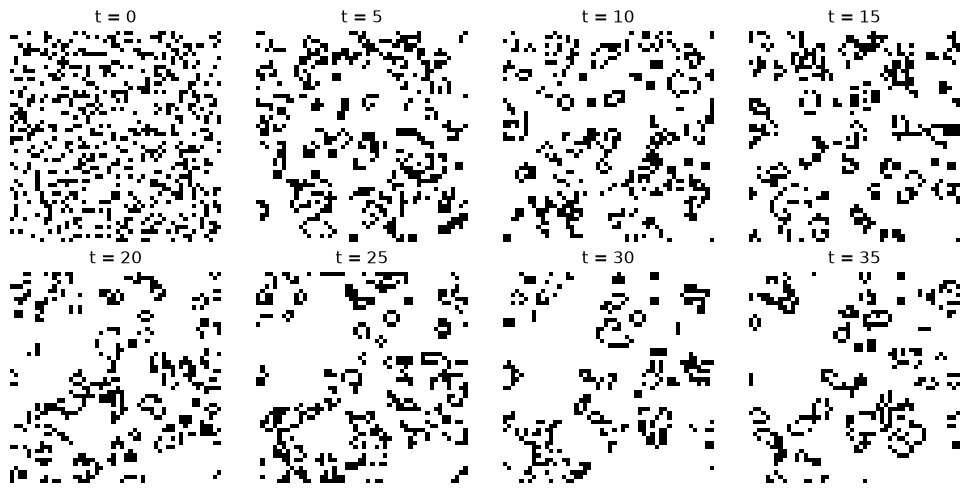

In [13]:
rng = np.random.default_rng(seed=42)

grid = (rng.random((50, 50)) < 0.25).astype(np.uint8)
print(f"grid: \n {grid}")
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()

for step in range(40):
    if step % 5 == 0:
        ax = axes[step // 5]
        ax.imshow(grid, cmap="binary", vmin=0, vmax=1)
        
        ax.set_title(f"t = {step}")
        ax.axis("off")

    grid = game_of_life_step(grid)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.signal import convolve2d

kernel = np.array([
    [1, 1, 1],
    [1, 0, 1],
    [1, 1, 1]
])


def game_of_life_step(grid):
    neighbors = convolve2d(
        grid,
        kernel,
        mode="same",
        boundary="wrap"
    )

    birth = (grid == 0) & (neighbors == 3)
    survival = (grid == 1) & np.isin(neighbors, [2, 3])

    return (birth | survival).astype(np.uint8)



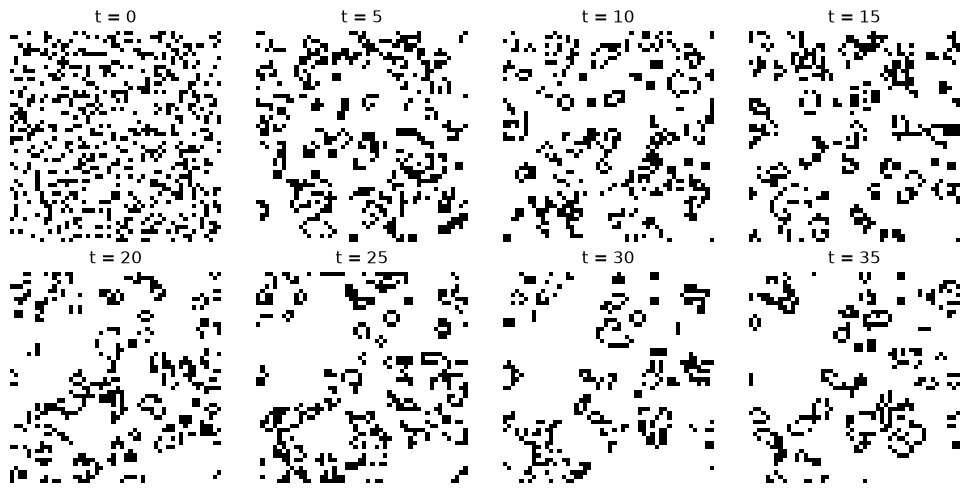

In [12]:
rng = np.random.default_rng(seed=42)

grid = (rng.random((50, 50)) < 0.25).astype(np.uint8)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()

for step in range(40):
    if step % 5 == 0:
        ax = axes[step // 5]
        ax.imshow(grid, cmap="binary", vmin=0, vmax=1)
        ax.set_title(f"t = {step}")
        ax.axis("off")

    grid = game_of_life_step(grid)

plt.tight_layout()
plt.show()

In [ ]:
import torch


def make_eca_rule_table(rule_number, device="cpu"):
    """
    Construct the outputs for neighbourhoods:

    index 0: 000
    index 1: 001
    index 2: 010
    ...
    index 7: 111
    """
    outputs = [
        (rule_number >> index) & 1
        for index in range(8)
    ]
    print(f"outputs \n {outputs}")

    return torch.tensor(
        outputs,
        dtype=torch.uint8,
        device=device
    )

rule_table = make_eca_rule_table(30)

print(rule_table)

tensor([0, 1, 1, 1, 1, 0, 0, 0], dtype=torch.uint8)


In [17]:
def eca_step(states, rule_table):
    """
    Apply one elementary cellular automaton update.

    states shape:     [batch_size, num_cells]
    rule_table shape: [8]

    Periodic boundary conditions are used.
    """
    if states.ndim != 2:
        raise ValueError(
            "states must have shape [batch_size, num_cells]"
        )

    # Periodic padding:
    #
    # original:        a b c d e
    # padded:        e a b c d e a
    #
    # The final cell is copied onto the left boundary.
    # The first cell is copied onto the right boundary.
    padded_states = torch.cat(
        [
            states[:, -1:],
            states,
            states[:, :1],
        ],
        dim=1,
    )

    # Extract every consecutive three-cell neighbourhood.
    #
    # padded shape:       [B, N + 2]
    # neighborhoods shape:[B, N, 3]
    #
    # For [e, a, b, c, d, e, a], the windows are:
    #
    # [e, a, b]
    # [a, b, c]
    # [b, c, d]
    # [c, d, e]
    # [d, e, a]
    neighborhoods = padded_states.unfold(
        dimension=1,
        size=3,
        step=1,
    )

    left = neighborhoods[:, :, 0]
    center = neighborhoods[:, :, 1]
    right = neighborhoods[:, :, 2]

    # Interpret [left, center, right] as a three-bit number:
    #
    # 000 -> 0
    # 001 -> 1
    # 010 -> 2
    # ...
    # 111 -> 7
    neighborhood_indices = (
        4 * left
        + 2 * center
        + right
    )

    # Lookup the output specified by the rule.
    next_states = rule_table[neighborhood_indices.long()]
    print("Padded:")
    print(padded_states)

    print("Neighbourhoods:")
    print(neighborhoods)

    print("Indices:")
    print(neighborhood_indices)

    return next_states

In [18]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

state = torch.tensor(
    [[0, 0, 0, 1, 0, 0, 0]],
    dtype=torch.uint8,
    device=device,
)

rule_table = make_eca_rule_table(
    rule_number=30,
    device=device,
)

next_state = eca_step(state, rule_table)

print("Current:", state)
print("Next:   ", next_state)

Padded:
tensor([[0, 0, 0, 0, 1, 0, 0, 0, 0]], dtype=torch.uint8)
Neighbourhoods:
tensor([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 1],
         [0, 1, 0],
         [1, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]], dtype=torch.uint8)
Indices:
tensor([[0, 0, 1, 2, 4, 0, 0]], dtype=torch.uint8)
Current: tensor([[0, 0, 0, 1, 0, 0, 0]], dtype=torch.uint8)
Next:    tensor([[0, 0, 1, 1, 1, 0, 0]], dtype=torch.uint8)


In [19]:
def explicit_rule30_step(states):
    padded_states = torch.cat(
        [
            states[:, -1:],
            states,
            states[:, :1],
        ],
        dim=1,
    )

    neighborhoods = padded_states.unfold(
        dimension=1,
        size=3,
        step=1,
    )

    left = neighborhoods[:, :, 0]
    center = neighborhoods[:, :, 1]
    right = neighborhoods[:, :, 2]

    return left ^ (center | right)

In [20]:
states = torch.randint(
    low=0,
    high=2,
    size=(1000, 128),
    dtype=torch.uint8,
    device=device,
)

table_result = eca_step(states, rule_table)
boolean_result = explicit_rule30_step(states)

assert torch.equal(table_result, boolean_result)

print("Implementations agree.")

Padded:
tensor([[0, 1, 1,  ..., 0, 0, 1],
        [0, 1, 1,  ..., 1, 0, 1],
        [0, 1, 1,  ..., 1, 0, 1],
        ...,
        [1, 0, 1,  ..., 1, 1, 0],
        [1, 0, 1,  ..., 0, 1, 0],
        [1, 0, 1,  ..., 0, 1, 0]], dtype=torch.uint8)
Neighbourhoods:
tensor([[[0, 1, 1],
         [1, 1, 1],
         [1, 1, 0],
         ...,
         [0, 1, 0],
         [1, 0, 0],
         [0, 0, 1]],

        [[0, 1, 1],
         [1, 1, 0],
         [1, 0, 0],
         ...,
         [1, 1, 1],
         [1, 1, 0],
         [1, 0, 1]],

        [[0, 1, 1],
         [1, 1, 0],
         [1, 0, 0],
         ...,
         [0, 1, 1],
         [1, 1, 0],
         [1, 0, 1]],

        ...,

        [[1, 0, 1],
         [0, 1, 0],
         [1, 0, 1],
         ...,
         [0, 1, 1],
         [1, 1, 1],
         [1, 1, 0]],

        [[1, 0, 1],
         [0, 1, 0],
         [1, 0, 0],
         ...,
         [1, 0, 0],
         [0, 0, 1],
         [0, 1, 0]],

        [[1, 0, 1],
         [0, 1, 1],
     